In [2]:
from __future__ import annotations

from pathlib import Path
import re
from typing import Dict, Optional


def read_simulation_time(log_file: str | Path) -> Dict[str, Optional[float]]:
    """Read simulation timing information from an md-flexible logOutput file.

    Returns a dictionary with:
    - metric: Which line was parsed ("Total wall-clock time", "Simulate", or "Total accumulated")
    - nanoseconds: Parsed time in ns (float)
    - seconds: Parsed time in s (float)
    - file: Absolute path to the parsed file
    """
    path = Path(log_file).expanduser().resolve()
    text = path.read_text(encoding="utf-8", errors="replace")

    patterns = [
        r"Total wall-clock time\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Simulate\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
        r"Total accumulated\s*:\s*([0-9]+(?:\.[0-9]+)?)\s*ns\s*\(([0-9]+(?:\.[0-9]+)?)s\)",
    ]
    labels = ["Total wall-clock time", "Simulate", "Total accumulated"]

    for label, pattern in zip(labels, patterns):
        match = re.search(pattern, text)
        if match:
            return {
                "metric": label,
                "nanoseconds": float(match.group(1)),
                "seconds": float(match.group(2)),
                "file": str(path),
            }

    raise ValueError(
        f"No known simulation-time pattern found in {path}. Expected one of: "
        "'Total wall-clock time', 'Simulate', or 'Total accumulated'."
    )


# Example:
# result = read_simulation_time(
#     "generated_inputs_rangeCheck/totalParticles_300000/sigmaRatio_0p15/countRatio_2p00/dataLayout_AoS/run_0/logOutput_155157_2.out"
# )
# print(result)


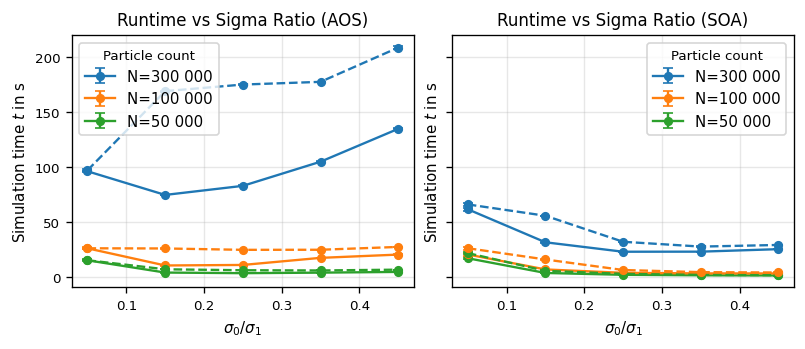

Saved: ../thesis_plots/rangeCheck.pdf
gap largest for around 0.15, but closer for smaller ratios. Could be because
1. yes we skip more cells, but also more cell combinations we have to calculate the distance of
3. (Since number of particles stays the same), Every skipped cell just contains less particles, because it is smaller->, at some point we are circular enough
At N=1000, (not shown for visual clarity), this actually makes range check off better sometimes 
Most importantly however, range checks throughout seem worth it 


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats as scipy_stats
    _HAS_SCIPY = True
except Exception:
    scipy_stats = None
    _HAS_SCIPY = False


def infer_total_particles_from_input(run_dir: Path) -> int | None:
    """Infer total particles from input.yaml if not encoded in path."""
    input_yaml = run_dir / "input.yaml"
    if not input_yaml.exists():
        return None

    total = 0
    pattern = re.compile(r"numberOfParticles\s*:\s*([0-9]+)")
    for line in input_yaml.read_text(encoding="utf-8", errors="replace").splitlines():
        m = pattern.search(line)
        if m:
            total += int(m.group(1))
    return total if total > 0 else None


def infer_range_check_mode(parts: tuple[str, ...]) -> str | None:
    """Infer whether a run belongs to rangeCheckOn or rangeCheckOff from path parts."""
    for token in parts:
        if token in {"rangeCheckOn", "rangeCheckOff"}:
            return token
    return None


def collect_runtime_data(base_dir: str | Path = ".") -> pd.DataFrame:
    """Collect simulation times from logOutput files under base_dir recursively."""
    base = Path(base_dir).expanduser().resolve()
    rows = []

    for log_path in base.rglob("logOutput_*.out"):
        parts = log_path.parts

        range_check = infer_range_check_mode(parts)
        if range_check is None:
            continue

        if not any(p.startswith("sigmaRatio_") for p in parts):
            continue
        if not any(p.startswith("dataLayout_") for p in parts):
            continue
        if not any(p.startswith("run_") for p in parts):
            continue

        sigma_ratio_str = next(p.split("_")[1] for p in parts if p.startswith("sigmaRatio_"))
        sigma_ratio = float(sigma_ratio_str.replace("p", "."))
        data_layout = next(p.split("_")[1] for p in parts if p.startswith("dataLayout_"))
        run = int(next(p.split("_")[1] for p in parts if p.startswith("run_")))

        total_dir = next((p for p in parts if p.startswith("totalParticles_")), None)
        if total_dir is not None:
            total_particles = int(total_dir.split("_")[1])
        else:
            total_particles = infer_total_particles_from_input(log_path.parent)
            if total_particles is None:
                continue

        timing = read_simulation_time(log_path)
        rows.append(
            {
                "range_check": range_check,
                "total_particles": total_particles,
                "sigma_ratio": sigma_ratio,
                "data_layout": data_layout,
                "run": run,
                "seconds": timing["seconds"],
                "log_file": str(log_path),
            }
        )

    return pd.DataFrame(rows)


def t_critical(confidence: float, dof: int) -> float:
    """Two-sided t critical value for a given central confidence and dof."""
    if dof <= 0:
        return 0.0

    p = (1.0 + confidence) / 2.0

    if _HAS_SCIPY:
        return float(scipy_stats.t.ppf(p, dof))

    z_lookup = {
        0.68: 0.994,
        0.86: 1.080,
        0.90: 1.645,
        0.95: 1.960,
        0.99: 2.576,
    }
    return z_lookup.get(round(confidence, 2), 1.96)


def apply_scrbook_11pt_style(use_latex=False):
    """Style settings tuned for thesis figures included at ~\textwidth in scrbook 11pt."""
    plt.rcParams.update(
        {
            "figure.dpi": 120,
            "savefig.dpi": 600,
            "font.size": 9,
            "axes.titlesize": 10,
            "axes.labelsize": 9,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "legend.fontsize": 8,
            "legend.title_fontsize": 8,
            "lines.linewidth": 1.4,
            "lines.markersize": 4.5,
            "axes.grid": True,
            "grid.alpha": 0.3,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "text.usetex": use_latex,
        }
    )


def plot_runtime_vs_sigma(
    df: pd.DataFrame,
    data_layout: str,
    ax=None,
    error_mode: str = "t86",
):
    """Plot mean runtime vs sigma ratio for one data layout with error bars."""
    subset = df[df["data_layout"].str.lower() == data_layout.lower()].copy()
    subset = subset[~subset["sigma_ratio"].round(2).eq(0.55)].copy()
    subset = subset[subset["total_particles"] != 1000].copy()
    if subset.empty:
        raise ValueError(f"No rows found for data_layout={data_layout!r}.")

    summary = (
        subset.groupby(["range_check", "total_particles", "sigma_ratio"], as_index=False)
        .agg(seconds_mean=("seconds", "mean"), seconds_std=("seconds", "std"), n=("seconds", "count"))
        .sort_values(["range_check", "total_particles", "sigma_ratio"])
    )

    summary["seconds_std"] = summary["seconds_std"].fillna(0.0)

    if error_mode == "std":
        summary["error"] = summary["seconds_std"]
    else:
        confidence = 0.86 if error_mode == "t86" else 0.95
        summary["se"] = summary["seconds_std"] / summary["n"].pow(0.5)
        summary["tcrit"] = summary["n"].apply(lambda n: t_critical(confidence, int(n - 1)))
        summary["error"] = summary["tcrit"] * summary["se"]

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))

    unique_particles = sorted(summary["total_particles"].unique(), reverse=True)
    colors = plt.cm.tab10(range(len(unique_particles)))
    particle_color_map = {p: colors[i] for i, p in enumerate(unique_particles)}

    line_styles = {"rangeCheckOn": "-", "rangeCheckOff": "--"}
    mode_order = ["rangeCheckOn", "rangeCheckOff"]
    labeled_particles = set()
    for mode in mode_order:
        mode_subset = summary[summary["range_check"] == mode]
        for total_particles, grp in mode_subset.groupby("total_particles"):
            color = particle_color_map[total_particles]
            label = f"N={total_particles:,}".replace(",", " ") if total_particles not in labeled_particles else "_nolegend_"
            labeled_particles.add(total_particles)
            ax.errorbar(
                grp["sigma_ratio"],
                grp["seconds_mean"],
                yerr=grp["error"],
                marker="o",
                linestyle=line_styles.get(mode, "-"),
                capsize=3,
                color=color,
                label=label,
            )

    ax.set_title(f"Runtime vs Sigma Ratio ({data_layout.upper()})")
    ax.set_xlabel(r"$\sigma_0 / \sigma_1$")
    ax.set_ylabel(r"Simulation time $t$ in s")
    ax.grid(True, alpha=0.3)
    handles, labels = ax.get_legend_handles_labels()
    order = sorted(
        range(len(labels)),
        key=lambda i: int(labels[i].split("=")[1].replace(" ", "")) if labels[i].startswith("N=") else -1,
        reverse=True,
    )
    ax.legend(
        [handles[i] for i in order],
        [labels[i] for i in order],
        title="Particle count",
        fontsize=9,
    )


# Collect data and generate one export-ready figure
runtime_df = collect_runtime_data(".")
runtime_df = runtime_df[runtime_df["total_particles"] != 1000].copy()

# If your LaTeX setup has full TeX support for Matplotlib, set this to True.
apply_scrbook_11pt_style(use_latex=False)

if runtime_df.empty:
    print("No logOutput_*.out files found below current directory.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(6.6, 2.8), sharey=True, constrained_layout=True)
    plot_runtime_vs_sigma(runtime_df, "AoS", ax=axes[0], error_mode="t86")
    plot_runtime_vs_sigma(runtime_df, "SoA", ax=axes[1], error_mode="t86")

    output_dir = Path("..") / "thesis_plots"
    output_dir.mkdir(exist_ok=True)

    pdf_path = output_dir / "rangeCheck.pdf"

    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    print(f"Saved: {pdf_path}")
    print("gap largest for around 0.15, but closer for smaller ratios. Could be because")
    print("1. yes we skip more cells, but also more cell combinations we have to calculate the distance of")
    print("3. (Since number of particles stays the same), Every skipped cell just contains less particles, because it is smaller->, at some point we are circular enough")
    print("At N=1000, (not shown for visual clarity), this actually makes range check off better sometimes ")
    print("Most importantly however, range checks throughout seem worth it ")

In [4]:
# Check whether rangeCheckOff is ever faster than rangeCheckOn for the same setup.
comparison_df = runtime_df[~runtime_df["sigma_ratio"].round(2).eq(0.55)].copy()

summary = (
    comparison_df.groupby(["range_check", "data_layout", "total_particles", "sigma_ratio"], as_index=False)
    .agg(mean_seconds=("seconds", "mean"), n=("seconds", "count"))
)

pivot = summary.pivot_table(
    index=["data_layout", "total_particles", "sigma_ratio"],
    columns="range_check",
    values="mean_seconds",
)

required_cols = {"rangeCheckOn", "rangeCheckOff"}
if not required_cols.issubset(set(pivot.columns)):
    print("Could not compare both modes for all settings (missing rangeCheckOn or rangeCheckOff).")
else:
    pivot = pivot.reset_index()
    pivot["off_minus_on_s"] = pivot["rangeCheckOff"] - pivot["rangeCheckOn"]
    better_off = pivot[pivot["off_minus_on_s"] < 0].sort_values("off_minus_on_s")

    total_points = len(pivot)
    print(f"Comparable settings: {total_points}")
    print(f"Settings where rangeCheckOff is faster: {len(better_off)}")

    if better_off.empty:
        print("Result: No, rangeCheckOff is never faster in this dataset.")
    else:
        print("Result: Yes, rangeCheckOff is faster for these settings:")
        display(better_off)

    # Optional overall means across all runs (excluding sigma=0.55).
    overall = (
        comparison_df.groupby("range_check", as_index=False)
        .agg(mean_seconds=("seconds", "mean"), median_seconds=("seconds", "median"), n=("seconds", "count"))
    )
    display(overall)

Comparable settings: 30
Settings where rangeCheckOff is faster: 0
Result: No, rangeCheckOff is never faster in this dataset.


,range_check,mean_seconds,median_seconds,n
0,rangeCheckOff,42.887733,24.3445,90
1,rangeCheckOn,27.519556,15.6410,90
